In [1]:
import pandas as pd

In [2]:
df=pd.read_excel(r'C:\Users\Philippe.ISOPE\Desktop\Theo Data Files\Boutons_variables\GluSnFR_avg_variables_allCa_filtered_3sigma.xlsx', sheet_name=1)
names=df['ID']

In [3]:
new_df=df.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3','Target'], axis=1) 
#df.drop(df.iloc[:,3:10])
new_df.head()
labels = new_df.columns
print (labels)
new_df.head()

Index(['AMP1', 'AMP2', 'PPR2/1', 'PPR3/1', 'PPR4/1', 'PPR5/1', 'PPR6/1',
       'PPR7/1', 'PPR8/1', 'PPR9/1', 'PPR10/1', '%Fail1', '%Fail2'],
      dtype='object')


,AMP1,AMP2,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2
0,0.246642,0.787000,3.190862,3.121936,3.041885,3.872012,2.853990,3.318133,3.198953,3.027747,3.580037,70.000000,30.0
1,0.445825,1.014894,2.276439,3.586167,3.246730,3.163963,2.649395,2.755458,2.695012,2.811947,3.171505,55.555556,0.0
2,0.627436,1.654345,2.636676,2.233680,3.285025,2.556900,2.956491,2.692657,2.928883,2.937819,3.246475,40.000000,0.0
3,0.543082,0.774586,1.426278,1.557859,1.267579,2.227367,1.069597,1.377519,1.888960,1.896043,1.822329,40.000000,50.0
4,0.580000,1.057000,1.822414,1.952988,1.238260,1.447025,1.541197,1.373654,1.553267,1.777128,1.658243,40.000000,20.0


In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
def apply_pca(df, n_components=None):
    # Standardize the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(new_df)
    # Apply PCA
    pca = PCA(n_components=n_components)
    transformed_data = pca.fit_transform(scaled_data)
    # Create a new DataFrame with the transformed data
    transformed_df = pd.DataFrame(transformed_data, columns=[f"PC{i+1}" for i in range(transformed_data.shape[1])])

    return transformed_df, pca

In [6]:
transformed_df, pca = apply_pca(new_df, n_components=2)

In [7]:
transformed_df.head()

,PC1,PC2
0,7.674240,0.694147
1,5.792760,2.075355
2,4.937350,3.539580
3,-0.180427,-0.948992
4,-0.463858,0.484696


In [8]:
print(" explained variance: ", pca.explained_variance_ratio_)
print (" pca components:  ", pca.components_)

 explained variance:  [0.5839683  0.20241261]
 pca components:   [[-0.21626655 -0.10425017  0.26062109  0.30888819  0.3250216   0.33037407
   0.32494576  0.3244983   0.32272136  0.32402288  0.32460522  0.19475338
   0.03021806]
 [ 0.421354    0.5419031   0.16057509  0.11551893  0.11459304  0.04833366
   0.05712486  0.0801919   0.06728836  0.07736981  0.07661815 -0.43070571
  -0.51246425]]


In [9]:
df_components = pd.DataFrame(pca.components_, columns = labels, index = ['PC_1', 'PC_2'])
df_components

,AMP1,AMP2,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2
PC_1,-0.216267,-0.104250,0.260621,0.308888,0.325022,0.330374,0.324946,0.324498,0.322721,0.324023,0.324605,0.194753,0.030218
PC_2,0.421354,0.541903,0.160575,0.115519,0.114593,0.048334,0.057125,0.080192,0.067288,0.077370,0.076618,-0.430706,-0.512464


In [10]:
full_table=pd.concat([transformed_df, new_df], axis=1, join='inner')

In [11]:
full_table_df=full_table.corr()

In [12]:
coeff_corr=full_table_df.iloc[0:2,2:]
coeff_corr

,AMP1,AMP2,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2
PC1,-0.595876,-0.287239,0.718085,0.851075,0.895527,0.910274,0.895318,0.894085,0.889189,0.892775,0.894379,0.536601,0.083259
PC2,0.683499,0.879047,0.260477,0.187389,0.185887,0.078404,0.092665,0.130083,0.109152,0.125505,0.124286,-0.698668,-0.831293


In [13]:
from sklearn.cluster import KMeans
n_clusters = 5

# Apply K-Means clustering
kmeans = KMeans(n_clusters=n_clusters, n_init= 'auto')
kmeans.fit(transformed_df)
# Get the cluster labels
cluster_labels = kmeans.labels_
# Add the cluster labels to the transformed DataFrame
transformed_df['Cluster'] = cluster_labels
new_df['Cluster'] = cluster_labels
Cluster_series=pd.Series(cluster_labels, name='Cluster')
CLuster_and_names=pd.concat([names,Cluster_series],axis=1)
CLuster_and_names
CLuster_and_names.to_excel('Clusters.xlsx')

C:\Users\Philippe.ISOPE\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


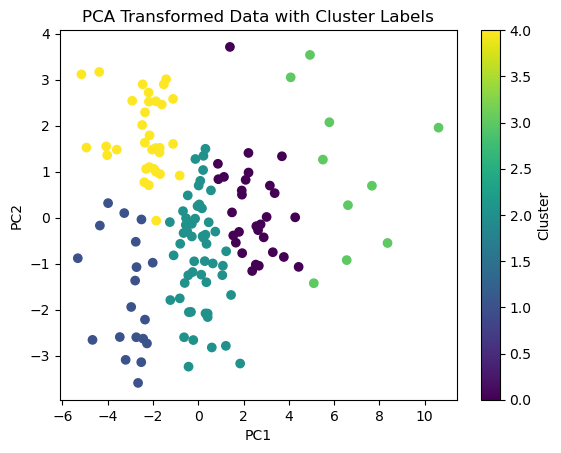

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.scatter(transformed_df['PC1'], transformed_df['PC2'], c=transformed_df['Cluster'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Transformed Data with Cluster Labels')
plt.colorbar(label='Cluster')
plt.show
plt.savefig('PCA.pdf')

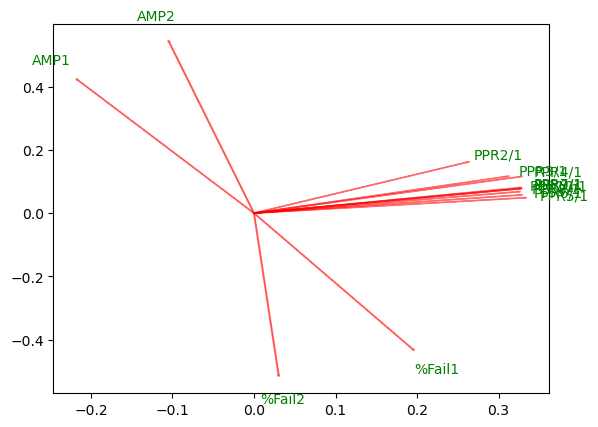

In [15]:
import numpy as np
coeff = np.transpose(pca.components_[0:2, :])
n = coeff.shape[0]
for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1],color = 'r',alpha = 0.5)
        plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')
plt.savefig('PCA components.pdf')

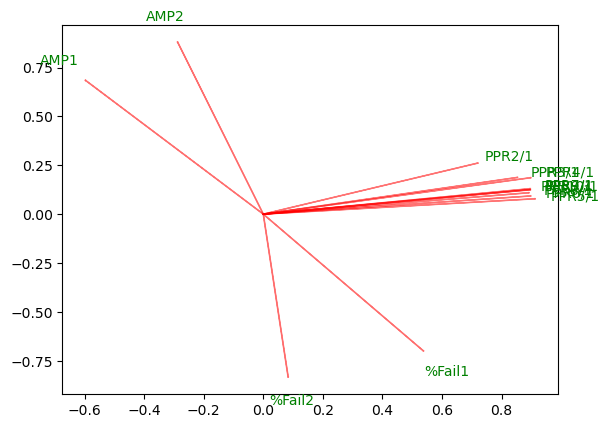

In [16]:
# same plot but with the coeff of correlation between variables and PC
coeff = np.transpose(coeff_corr)
n = coeff.shape[0]
arr=coeff.to_numpy()
for i in range(n):
        plt.arrow(0, 0, arr[i,0], arr[i,1],color = 'r',alpha = 0.5)
        plt.text(arr[i,0]* 1.15, arr[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')
plt.savefig('PCA components.pdf')

In [17]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np

# Assuming you have the transformed DataFrame 'transformed_df' with the 'Cluster' column
# Calculate the silhouette score
silhouette_avg = silhouette_score(transformed_df, transformed_df['Cluster'])
print('Silhouette Score:', silhouette_avg)

Silhouette Score: 0.5151012753276656


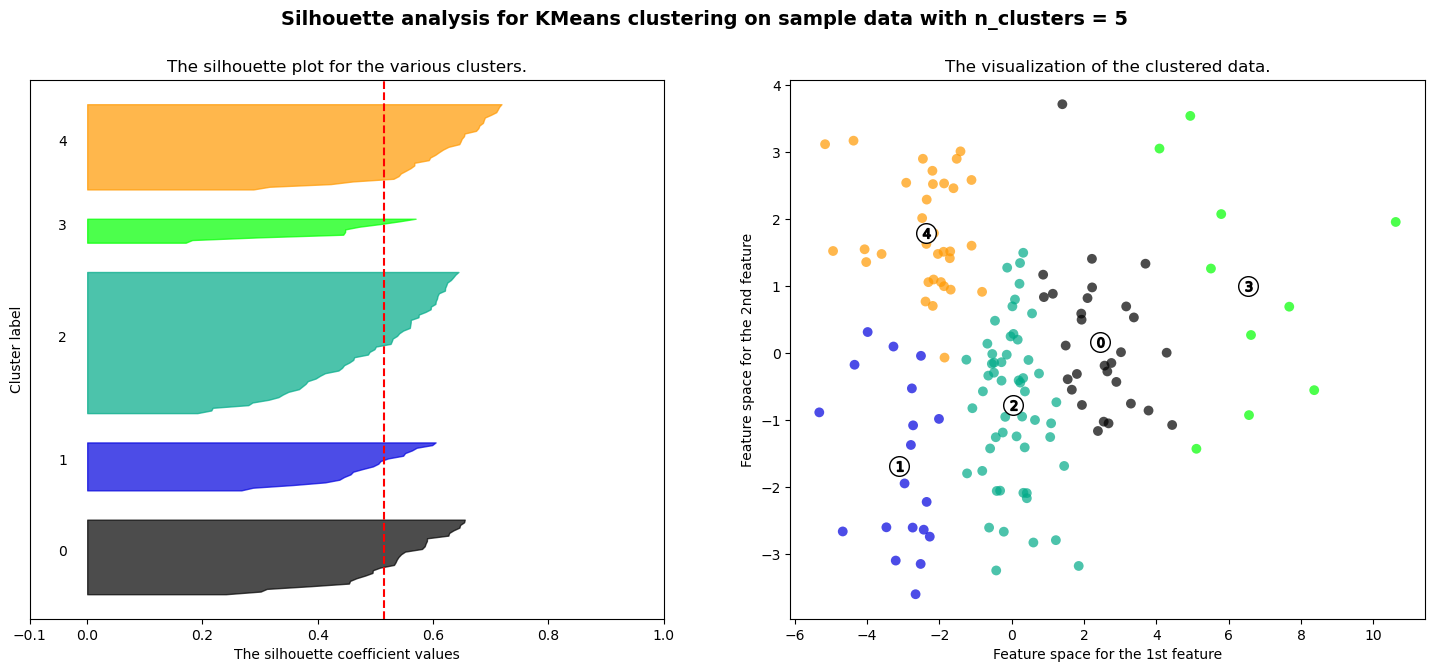

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)

sample_silhouette_values = silhouette_samples(transformed_df, transformed_df['Cluster'])

y_lower = 10
for i in range(n_clusters):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values[transformed_df['Cluster'] == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_clusters)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("The silhouette plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# 2nd Plot showing the actual clusters formed
colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
ax2.scatter(
    transformed_df['PC1'], transformed_df['PC2'], marker=".", s=200, lw=0, alpha=0.7, c=colors, edgecolor="k"
)
# Labeling the clusters
centers = kmeans.cluster_centers_
# Draw white circles at cluster centers
ax2.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="o",
    c="white",
    alpha=1,
    s=200,
    edgecolor="k",
)
for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

ax2.set_title("The visualization of the clustered data.")
ax2.set_xlabel("Feature space for the 1st feature")
ax2.set_ylabel("Feature space for the 2nd feature")
plt.suptitle(
    "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
    % n_clusters,
    fontsize=14,
    fontweight="bold",
)

plt.savefig('Silhouette scores.pdf')

In [19]:
full_table['Cluster'] = cluster_labels
print (full_table.groupby('Cluster').mean())
full_table_PPR=full_table.drop(['AMP1','AMP2','PC1', 'PC2', '%Fail1', '%Fail2'], axis=1)
full_table_PPR['Cluster'] = cluster_labels
PPR0=np.ones(145)
full_table_PPR.insert(loc=0, column='PPR0', value=PPR0)
full_table_PPR
PPR_clusters=full_table_PPR.groupby('Cluster').mean()
T_cluster=np.transpose(PPR_clusters)
T_cluster

              PC1       PC2      AMP1      AMP2    PPR2/1    PPR3/1    PPR4/1  \
Cluster                                                                         
0        2.435684  0.161034  0.279486  0.640713  2.357698  2.401302  2.239475   
1       -3.106505 -1.675588  0.437802  0.522450  1.215952  1.091346  0.970604   
2        0.030175 -0.776340  0.326316  0.575004  1.766395  1.763160  1.598061   
3        6.526411  0.995496  0.294617  0.755887  2.565032  3.278821  3.157802   
4       -2.378933  1.791928  0.757336  1.210969  1.653253  1.479149  1.383007   

           PPR5/1    PPR6/1    PPR7/1    PPR8/1    PPR9/1   PPR10/1  \
Cluster                                                               
0        2.156887  2.016747  2.070817  1.964368  1.957076  2.044041   
1        0.962793  0.967458  0.853690  0.814029  0.793604  0.811273   
2        1.640759  1.603654  1.494273  1.537950  1.577186  1.503248   
3        3.099484  3.091206  2.960838  3.006796  3.001869  3.119647   
4     

Cluster,0,1,2,3,4
PPR0,1.000000,1.000000,1.000000,1.000000,1.000000
PPR2/1,2.357698,1.215952,1.766395,2.565032,1.653253
PPR3/1,2.401302,1.091346,1.763160,3.278821,1.479149
PPR4/1,2.239475,0.970604,1.598061,3.157802,1.383007
PPR5/1,2.156887,0.962793,1.640759,3.099484,1.259617
PPR6/1,2.016747,0.967458,1.603654,3.091206,1.218078
PPR7/1,2.070817,0.853690,1.494273,2.960838,1.142468
PPR8/1,1.964368,0.814029,1.537950,3.006796,1.147627
PPR9/1,1.957076,0.793604,1.577186,3.001869,1.150017
PPR10/1,2.044041,0.811273,1.503248,3.119647,1.068336


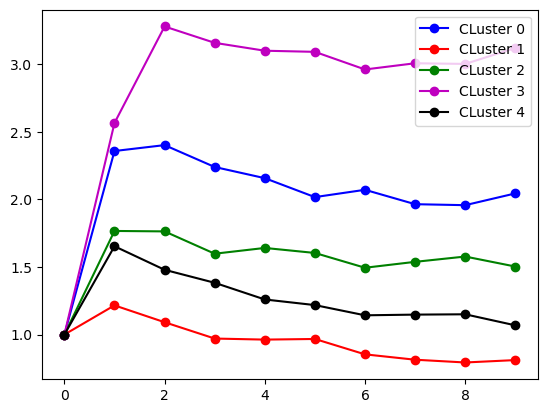

In [20]:
x=np.arange(10)
color=['b', 'r', 'g', 'm', 'k']
for i in range(n_clusters):
     plt.plot(x,T_cluster.iloc[:,i], '-o', color=color[i], label=f'CLuster {i}')
plt.legend(loc='upper right')
plt.savefig('Cluster Profiles.pdf')

In [21]:
new_df

,AMP1,AMP2,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2,Cluster
0,0.246642,0.787000,3.190862,3.121936,3.041885,3.872012,2.853990,3.318133,3.198953,3.027747,3.580037,70.000000,30.0,3
1,0.445825,1.014894,2.276439,3.586167,3.246730,3.163963,2.649395,2.755458,2.695012,2.811947,3.171505,55.555556,0.0,3
2,0.627436,1.654345,2.636676,2.233680,3.285025,2.556900,2.956491,2.692657,2.928883,2.937819,3.246475,40.000000,0.0,3
3,0.543082,0.774586,1.426278,1.557859,1.267579,2.227367,1.069597,1.377519,1.888960,1.896043,1.822329,40.000000,50.0,2
4,0.580000,1.057000,1.822414,1.952988,1.238260,1.447025,1.541197,1.373654,1.553267,1.777128,1.658243,40.000000,20.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,0.424167,0.756589,1.783707,2.083987,1.943073,1.910329,1.858608,1.899657,1.654553,1.891774,2.266839,30.000000,0.0,0
141,0.406005,0.744110,1.832762,1.835540,1.956329,2.019905,1.696891,2.099301,1.731058,1.927536,1.903097,10.000000,0.0,0
142,0.495801,0.957000,1.930210,2.081480,1.794048,1.913789,1.776977,1.569178,1.703521,1.401860,1.731051,20.000000,0.0,2
143,0.797845,1.637000,2.051777,1.637680,1.568489,1.713416,1.685791,1.098086,1.201086,1.372447,1.542837,0.000000,0.0,4


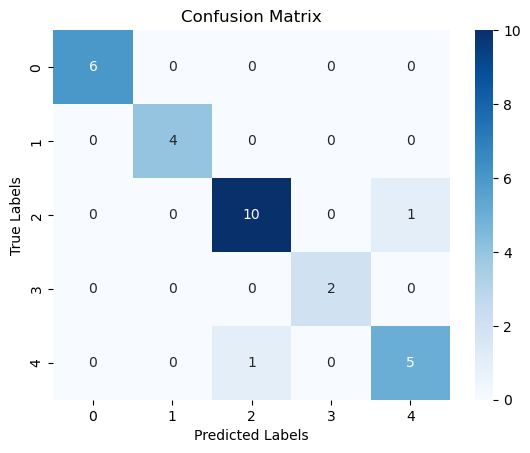

Cross-validation scores: [0.95833333 0.91304348 0.86956522 0.86956522 0.86956522]
Mean cross-validation score: 0.8960144927536232
Accuracy on the test set: 0.9310344827586207


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix

# Separate the features (X) and the target variable (y)
X = new_df.iloc[:, :-1]
y = new_df.iloc[:, -1]

# Split the data into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create a random forest classifier
rf = RandomForestClassifier()

# Perform cross-validation with K-fold of 5
cv_scores = cross_val_score(rf, X_train, y_train, cv=5)

# Fit the model to the training data
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf.predict(X_test)

# Create the confusion matrix
confusion = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())

# Print the accuracy of the model on the test set
accuracy = (y_pred == y_test).mean()
print("Accuracy on the test set:", accuracy)

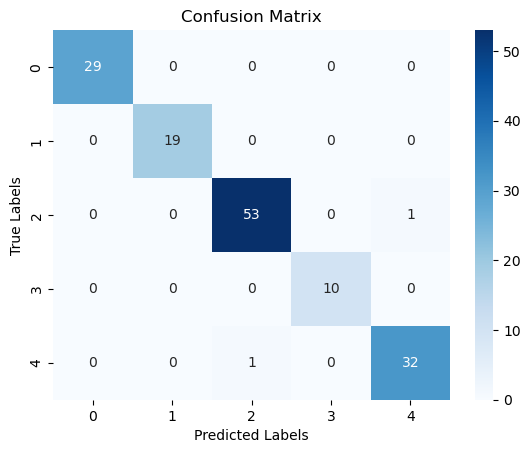

Cross-validation scores: [0.95833333 0.91304348 0.86956522 0.86956522 0.86956522]
Mean cross-validation score: 0.8960144927536232
Accuracy on the entire dataset: 0.9862068965517241


In [23]:
# Make predictions on the entire dataset
y_pred = rf.predict(X)
# Create the confusion matrix
confusion = confusion_matrix(y, y_pred)

# Plot the confusion matrix
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())

# Print the accuracy of the model on the entire dataset
accuracy = (y_pred == y).mean()
print("Accuracy on the entire dataset:", accuracy)